In [2]:
# Importing necessary libraries
# Data based on https://www.youtube.com/watch?v=k8yIvVFCguA

from stoneforge.pseudo_wells import anadrill_siliciclastic, color_codes, lithology_generator
from stoneforge.pseudo_wells.pseudo_tools import merge_lithology
from stoneforge.data_management import resampling
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [3]:
# Empty function returns available facies

anadrill_siliciclastic()

0 shale
1 clean_sandstone with gas
2 clean_sandstone with oil
3 clean_sandstone with brine
4 feldspatic sandstone
5 unconsolidated sandstone with fresh water
6 organic shale
7 siltite
8 dirty sandstone with brine


In [4]:
# generating synthetic lithology data

# 1 - Defining markov chain transition probabilities
markov_chain = np.array(
    [[0.93, 0.07, 0.00, 0.00], # Shale
    [0.02, 0.97, 0.01, 0.00], # Sandstone
    [0.05, 0.10, 0.85, 0.00], # Arcose
    [0.00, 0.00, 0.00, 0.00]] # Sandstone mixed with clay
    )

# 2 - Generating synthetic lithology data using the defined markov chain
markov_lithology = lithology_generator.simple(markov_chain,
    lithology_code  = [0,3,4,8],
    sampling = 3000,
    initial_state = 0
)

# 3 - Merging lithology data into a occurrence and lithology column format
data_entry = merge_lithology(markov_lithology)

In [5]:
# Generating well log data based on lithology data from markov generator (anadrill based)

well_1,units_1 = anadrill_siliciclastic(data_entry, top = 800.0, step=0.10, random_state=42)

data_1 = pd.DataFrame.from_dict(well_1)
data_1

,DEPTH,GR,RES,NPHI,DEN,DT,CODE,ROCK,FLUID
0,800.1,111.441208,5.303770,0.278614,2.549506,103.955661,57,shale,none
1,800.2,24.406524,0.904510,0.132896,2.733874,67.645464,49,clean_sandstone,brine
2,800.3,24.674493,0.907448,0.133151,2.749514,68.094024,49,clean_sandstone,brine
3,800.4,24.460925,0.905599,0.132469,2.746113,67.918264,49,clean_sandstone,brine
4,800.5,24.543767,0.900855,0.133920,2.731992,67.789730,49,clean_sandstone,brine
...,...,...,...,...,...,...,...,...,...
2995,1099.6,24.522851,0.905256,0.132586,2.738773,67.418532,49,clean_sandstone,brine
2996,1099.7,24.675604,0.905586,0.133144,2.749481,67.823351,49,clean_sandstone,brine
2997,1099.8,24.490581,0.910136,0.134332,2.724624,67.896587,49,clean_sandstone,brine
2998,1099.9,24.694839,0.903579,0.133503,2.744773,67.744221,49,clean_sandstone,brine


In [6]:
# Resampling the data to a step of 10 cm and between 1600 and 1800 m depth using nearest mode

sub_data_nearest_1 = resampling(data_1, "DEPTH", step = 0.30, top=1000.0, bottom=1100.0, mode="nearest")
sub_data_nearest_1

,DEPTH,GR,RES,NPHI,DEN,DT,CODE,ROCK,FLUID
0,1000.0,24.765475,0.903647,0.133164,2.749480,67.873113,49,clean_sandstone,brine
1,1000.3,24.672823,0.903059,0.133373,2.744291,67.658773,49,clean_sandstone,brine
2,1000.6,24.500236,0.902612,0.132048,2.724348,68.110521,49,clean_sandstone,brine
3,1000.9,24.720341,0.910891,0.133442,2.763376,67.814171,49,clean_sandstone,brine
4,1001.2,24.568927,0.900180,0.132277,2.723036,68.068489,49,clean_sandstone,brine
...,...,...,...,...,...,...,...,...,...
330,1099.0,24.417712,0.899732,0.132364,2.726524,67.732338,49,clean_sandstone,brine
331,1099.3,24.415876,0.903627,0.134260,2.722444,67.891929,49,clean_sandstone,brine
332,1099.6,24.522851,0.905256,0.132586,2.738773,67.418532,49,clean_sandstone,brine
333,1099.9,24.694839,0.903579,0.133503,2.744773,67.744221,49,clean_sandstone,brine


In [7]:
# Resampling the data to a step of 10 cm and between 1600 and 1800 m depth using mean mode

sub_data_mean_1 = resampling(data_1, "DEPTH", step = 0.30, top=1000.0, bottom=1100.0, mode="mean")
sub_data_mean_1

,DEPTH,GR,RES,NPHI,DEN,DT,CODE,ROCK,FLUID
0,1000.0,24.676801,0.905822,0.132645,2.739842,68.044990,49.0,clean_sandstone,brine
1,1000.3,24.575668,0.906138,0.133047,2.724486,67.907808,49.0,clean_sandstone,brine
2,1000.6,24.547521,0.905025,0.132874,2.737878,68.050348,49.0,clean_sandstone,brine
3,1000.9,24.484615,0.906256,0.132655,2.735981,67.964367,49.0,clean_sandstone,brine
4,1001.2,24.577168,0.901188,0.132078,2.732280,67.991642,49.0,clean_sandstone,brine
...,...,...,...,...,...,...,...,...,...
330,1099.0,24.479403,0.899492,0.132635,2.729947,67.836921,49.0,clean_sandstone,brine
331,1099.3,24.456230,0.903215,0.133061,2.727942,67.809664,49.0,clean_sandstone,brine
332,1099.6,24.579055,0.902441,0.132807,2.743072,67.571914,49.0,clean_sandstone,brine
333,1099.9,24.601132,0.905873,0.133377,2.729991,67.784807,49.0,clean_sandstone,brine


In [8]:
# Resampling the data to a step of 10 cm and between 1600 and 1800 m depth using least_squares

sub_data_least_squares_1 = resampling(data_1, "DEPTH", step = 0.30, top=1000.0, bottom=1100.0, mode="least_squares")
sub_data_least_squares_1

,DEPTH,GR,RES,NPHI,DEN,DT,CODE,ROCK,FLUID
0,1000.0,24.765475,0.903647,0.133164,2.749480,67.873113,49.0,clean_sandstone,brine
1,1000.3,24.575668,0.906138,0.133047,2.724486,67.907808,49.0,clean_sandstone,brine
2,1000.6,24.547521,0.905025,0.132874,2.737878,68.050348,49.0,clean_sandstone,brine
3,1000.9,24.484615,0.906256,0.132655,2.735981,67.964367,49.0,clean_sandstone,brine
4,1001.2,24.577168,0.901188,0.132078,2.732280,67.991642,49.0,clean_sandstone,brine
...,...,...,...,...,...,...,...,...,...
330,1099.0,24.479403,0.899492,0.132635,2.729947,67.836921,49.0,clean_sandstone,brine
331,1099.3,24.456230,0.903215,0.133061,2.727942,67.809664,49.0,clean_sandstone,brine
332,1099.6,24.579055,0.902441,0.132807,2.743072,67.571914,49.0,clean_sandstone,brine
333,1099.9,24.601132,0.905873,0.133377,2.729991,67.784807,49.0,clean_sandstone,brine


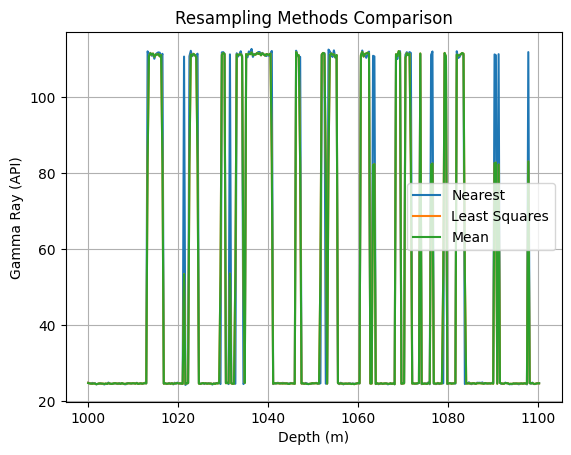

In [9]:
plt.plot(sub_data_nearest_1['DEPTH'], sub_data_nearest_1['GR'], label='Nearest')
plt.plot(sub_data_least_squares_1['DEPTH'], sub_data_least_squares_1['GR'], label='Least Squares')
plt.plot(sub_data_mean_1['DEPTH'], sub_data_mean_1['GR'], label='Mean')
plt.legend()
plt.xlabel('Depth (m)')
plt.ylabel('Gamma Ray (API)')
plt.title('Resampling Methods Comparison')
plt.grid()
plt.show()